In [1]:
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import PolynomialLR
from torch.utils.data import WeightedRandomSampler
from torchvision.transforms import v2

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm.notebook import tqdm
import json
import cv2
import numpy as np
###IE###
%load_ext autoreload
%autoreload 2
from utils.helpers import  plot_some_images ,read_images , pre_hard_skeletonize , pre_soft_skeletonize,compute_confution_matrix
from utils.preprocessing import WhiteTopHat , CLAHE , normalize_xca
from utils.dataset import  UnetDataset , ValidUnetDataset
from models.nnunet import nnUnet
from models.nnunet_blocks import nnUnetv2
from models.swin_encoder import SwinEncoder , SwinUperNet
from utils.losses import UnetLoss
from utils.recorder import HistoryRecorder
from logger import save_full_report
from trainer import trainer
###SS###

# Training

In [ ]:
args = {
    "base_path" : "../arcade/nnUnet_dataset/syntax",
    "in_c" : 3,
    "base_channel" :32,
    "image_shape" : (384,384),
    "class_count" : 26 ,
    "attention" : True,
    "k":40,
    "batch_size" : 8,
    "num_workers" : 10,
    "device" : "cuda" if torch.cuda.is_available() else "cpu",
    "lr" : 0.001,
    "momentum" : 0.99,
    "weight_decay" : 0.001,
    "epcohs":30,
    "f_int_scale" : 2,
    "full_report_cycle" : 10,
    "max_channels":512,
    "unet_depth":6,
    "loss_type":"tversky loss",
    "alpha":0.3,
    "beta":0.7,
    "t_gamma":2.0,
    "f_gamma":2.0,
    "f_loss_scale":1,
    "loss_coefs":{"CE":1.0,"Second":1.0},
    "swin_head" : "costume",
    "swin_type":"swin_v2_b",
    "output_base_path" : "./outputs",
    "name" : "Attention7-DSV-tev-new_augs-swin_upernet_base_img-FCE",
    "deep_super_vision" : False,
    "use_sch":False,
    "f_alpha":None
}
class_map = {
    1: '1',2: '2', 3: '3',4: '4',
    5: '5',6: '6',7: '7',8: '8',
    9: '9',10: '9a',11: '10',12: '10a',
    13: '11',14: '12',15: '12a',16: '13',
    17: '14',18: '14a',19: '15',20: '16',
    21: '16a',22: '16b',23: '16c',
    24: '12b',25: '14b'
}
train_class_counts = [
    1000,374,375,369,303,525,525,
    340,310,198,70,21,1,320,61,
    129,305,107,49,38,232,43,48,31,63,127
]
train_pixel_counts = [
    253576361,664435,686727,661957,
    480566,591829,816901,685677,570436,
    470633,124025,23866,1079,507754,151219,
    336857,597880,241117,98167,66890,322098,
    49426,63543,36457,164558,153542
]
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
# losses_keys = ["total loss","FCE loss",args["loss_type"]]
losses_keys = ["total loss","FCE loss",args["loss_type"]]
out_counts = 5 if args["deep_super_vision"] else 1
loss_weights = [1/(2**i) for i in range(out_counts)]
loss_weights

[1.0]

In [3]:
def class_weighting(method,class_counts,**kwargs):
    if(kwargs["use_pixel_counts"]):
        print("using pixel counts")
        with open("./data/train_class_counts.json","r") as f:
            train_class_counts = json.load(f)
        counts = [0]*(len(train_class_counts))
        for k,v in train_class_counts.items():
            counts[int(k)] = int(v)
        counts = np.array(counts,dtype=np.float64)
    else :
        print("using class counts")
        counts = np.array(class_counts,dtype=np.float64)

    if(method=="median"):
        print("median weights being used")
        median_count = np.median(counts)
        weights = median_count/np.array(counts)
        
    elif(method=="log"):
        print("log weights being used")
        total = np.sum(counts)
        weights = np.log(total/np.array(counts))
        weights = (weights / weights.mean())
        weights[0]=0.1
    elif(method=="beta"):
        print("beta weights being used")
        b = kwargs["b"]
        weights = (1-b)/(1-np.power(b,counts))
        weights = weights / weights.sum()
        weights[12] = 0.25
    else:
        print("no class weights being used")
        return None
    return weights.tolist()
args["f_alpha"] = class_weighting(method="none",class_counts=train_class_counts,b=0.999999,use_pixel_counts=False)
args["f_alpha"]

using class counts
no class weights being used


In [4]:
# pre_soft_skeletonize(args["base_path"],output_path=args["base_path"],batch_size=10,k=40)

In [5]:
def morph_binary_mask(x, **kwargs):
    m = x.copy()

    if m.ndim == 3:
        m2 = m[..., 0]
    else:
        m2 = m

    m2 = (m2 > 0).astype(np.uint8)

    if np.random.rand() < 0.5:
        k = np.ones((3, 3), np.uint8)
        if np.random.rand() < 0.5:
            m2 = cv2.dilate(m2, k, iterations=1)
        else:
            m2 = cv2.erode(m2, k, iterations=1)

    if np.random.rand() < 0.5:
        blurred = cv2.GaussianBlur(m2.astype(np.float32), (3, 3), 0)
        m2 = (blurred > 0.5).astype(np.uint8)

    if np.random.rand() < 0.5:
        h, w = m2.shape        
        for _ in range(200):
            y = np.random.randint(0, h)
            x = np.random.randint(0, w)
            m2[y, x] = 0

    
    if m.ndim == 3:
        m_out = m2[..., None]
    else:
        m_out = m2

    return m_out

In [6]:
train_transforms = A.Compose([
    # A.RandomCrop(args["image_shape"][0],args["image_shape"][1]),
    A.Resize(*args["image_shape"]),
    A.OneOf([
        A.ElasticTransform(
            alpha=120, 
            sigma=120 * 0.05, 
            p=1.0
        ),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
        A.OpticalDistortion(distort_limit=0.2, p=1.0),
    ], p=0.7),


    A.Affine(
        scale=(0.8, 1.2),             
        translate_percent=(-0.1, 0.1), 
        rotate=(-30, 30),         
        shear=(-10, 10),      
        

        fill=0,           
        fill_mask=0,                 
        border_mode=cv2.BORDER_CONSTANT, 
        
        fit_output=False,  
        p=0.7
    ),

    # A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.5),

    # A.RandomBrightnessContrast(
    #     brightness_limit=0.2, 
    #     contrast_limit=0.2, 
    #     p=0.5
    # ),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    # A.Lambda(image=morph_binary_mask, p=1),

    # A.Lambda(image=normalize_xca)
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
                max_pixel_value=255.0
    ),
    ToTensorV2()

])
test_transforms = A.Compose([
    # A.RandomCrop(args["image_shape"][0],args["image_shape"][1]),
    A.Resize(*args["image_shape"]),
    # A.Lambda(image=normalize_xca),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
                max_pixel_value=255.0
                ),
    ToTensorV2(),
    ]  
)
# train_preprocess = v2.Compose([
#     WhiteTopHat(kernel_size=(50,50)),
#     CLAHE()
    
# ])
train_preprocess = None


In [7]:
def make_dataloader(data,args,valid=False,sampler_weights=None):
    if(sampler_weights is not None):
        print("using weighted sampler here")
        sampler = WeightedRandomSampler(sampler_weights, len(sampler_weights))
        dataloader = DataLoader(
            data,
            batch_size = args["batch_size"] ,
            num_workers = args["num_workers"] ,
            pin_memory=True,
            shuffle=False,
            sampler=sampler
        )
        
    else : 
        if(valid):
            print("valid with no sampler")
            dataloader = DataLoader(
                data,
                batch_size = args["batch_size"] ,
                num_workers = args["num_workers"] ,
                pin_memory=True,
                shuffle=False,
            )
        else : 
            print("train with no sampler")
            dataloader = DataLoader(
                data,
                batch_size = args["batch_size"] ,
                num_workers = args["num_workers"] ,
                pin_memory=True,
                shuffle=True
            )
    return dataloader

In [8]:

train_images,sampler_weights = read_images(
    base_path = args["base_path"],
    preprocessor = train_preprocess,
    part = "train",
    train_class_counts=np.array(train_pixel_counts),
    in_c = args["in_c"]
    # mode = args["train_mode"]
)
valid_images = read_images(
    base_path = args["base_path"],
    preprocessor = train_preprocess,
    part = "val",
    train_class_counts=None,
    in_c=args["in_c"]
    # mode = args["train_mode"]
)
# print(sampler_weights)
train_ds = UnetDataset(transform = train_transforms,data = train_images,base_size=args["image_shape"][0],out_counts=out_counts)
valid_ds = ValidUnetDataset(transform = test_transforms,data = valid_images)

train_loader = make_dataloader(train_ds,args,valid=False,sampler_weights=sampler_weights)
valid_loader = make_dataloader(valid_ds,args,valid=True,sampler_weights=None)

max count is :  816901
NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/1000 [00:00<?, ?it/s]

NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/200 [00:00<?, ?it/s]

using weighted sampler here
valid with no sampler


In [9]:
# plot_some_images(train_images, train_transforms, mean=IMAGENET_MEAN,std=IMAGENET_STD,image_counts=36, fig_shape=(6,6), base_transforms=test_transforms)

In [ ]:
model = SwinUperNet(args).to(args["device"])

loss_fn = UnetLoss(args)
# optimizer = torch.optim.Adam(model.parameters(), lr=args["lr"])
# optimizer = torch.optim.SGD(
#     model.parameters(),
#     momentum=args["momentum"],
#     lr=args["lr"],
#     nesterov=True,
#     weight_decay=args["weight_decay"]
# )
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=args["lr"], 
    betas=(0.9, 0.999), 
    eps=1e-08, 
    weight_decay=args["weight_decay"]
)
if(args["use_sch"]):
    lr_sch = PolynomialLR(optimizer=optimizer,total_iters=args["epcohs"],power=0.9)
else:
    lr_sch = None
recorder = HistoryRecorder(losses_keys=losses_keys,class_maps =class_map)

best_model =trainer(
    args=args,
    recorder = recorder,
    model = model,
    optimizer = optimizer,
    loss_fn = loss_fn,
    train_loader = train_loader,
    valid_loader = valid_loader,
    loss_weights=loss_weights,
    lr_sch = lr_sch
)

loss is set to tversky


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/125 [00:00<?, ?it/s]

current lr : 0.001
train ==> epcoh (0)
total loss : 1.728024510860443 - FCE loss : 0.8101469606757165 - tversky loss : 0.9178775482177735

train avg metrics for epoch 0 :
avg dice : 0.057936355030747816 - avg precision : 0.07542549626436085 - avg recall : 0.05380184780718991
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (0)
total loss : 1.0843843936920166 - FCE loss : 0.16065524905920028 - tversky loss : 0.9237291359901428

valid avg metrics for epoch 0 :
avg dice : 0.06003034131903518 - avg precision : 0.10228927418589592 - avg recall : 0.08394239406683482
------------------------------------------------------------
New Best! : dice = 0.060030341148376465


  0%|          | 0/125 [00:00<?, ?it/s]

...

current lr : 0.0001259
train ==> epcoh (27)
total loss : 0.5839204246997833 - FCE loss : 0.09355846065282822 - tversky loss : 0.49036196422576905

train avg metrics for epoch 27 :
avg dice : 0.4132592993974686 - avg precision : 0.39567061603069303 - avg recall : 0.4389819797873497
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (27)
total loss : 0.6687003457546234 - FCE loss : 0.10220367521047592 - tversky loss : 0.5664966678619385

valid avg metrics for epoch 27 :
avg dice : 0.3098488797248865 - avg precision : 0.2977353948354721 - avg recall : 0.3436909456923604
------------------------------------------------------------
New Best! : dice = 0.3098488748073578


  0%|          | 0/125 [00:00<?, ?it/s]

current lr : 8.74e-05
train ==> epcoh (28)
total loss : 0.5667314722537994 - FCE loss : 0.09099305790662765 - tversky loss : 0.47573841547966006

train avg metrics for epoch 28 :
avg dice : 0.42464348196983337 - avg precision : 0.4052978575229645 - avg recall : 0.4509048357605934
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (28)
total loss : 0.6626459789276123 - FCE loss : 0.09814634323120117 - tversky loss : 0.5644996392726899

valid avg metrics for epoch 28 :
avg dice : 0.32065566271556706 - avg precision : 0.3320896526426077 - avg recall : 0.3338108709082007
------------------------------------------------------------
New Best! : dice = 0.3206556737422943


  0%|          | 0/125 [00:00<?, ?it/s]

current lr : 4.684e-05
train ==> epcoh (29)
total loss : 0.5799590435028076 - FCE loss : 0.09533272704482079 - tversky loss : 0.48462631487846375

train avg metrics for epoch 29 :
avg dice : 0.414691578745842 - avg precision : 0.3984999400377274 - avg recall : 0.4381422188878059
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (29)
total loss : 0.6535921978950501 - FCE loss : 0.09753750652074814 - tversky loss : 0.5560546863079071

valid avg metrics for epoch 29 :
avg dice : 0.3196808612347859 - avg precision : 0.3098637883365154 - avg recall : 0.3488295477628708
1 => dice : 0.6190928220748901 p : 0.7143115997314453 , r : 0.5462737679481506
2 => dice : 0.6438990831375122 p : 0.6446223855018616 , r : 0.6431773900985718
3 => dice : 0.6303697228431702 p : 0.6078447103500366 , r : 0.6546283960342407
4 => dice : 0.48029080033302307 p : 0.42131567001342773 , r : 0.5584637522697449
5 => dice : 0.6323180794715881 p : 0.5754696726799011 , r : 0.7016294002532959
6 => 

Save Model
Saving Memory
Saving All Plots
Saving Examples
Saving Verbal Results
Copying Notebook To Results
builfding kaggle project


100%|██████████| 11/11 [00:00<00:00, 2977.18it/s]


processing ./utils/dataset.py
processing ./utils/helpers.py
processing ./logger.py
processing ./utils/preprocessing.py
processing ./utils/recorder.py
processing ./models/costume_nnunet_blocks.py
processing ./models/nnunet.py
processing ./models/swin_encoder.py
processing ./models/swin_blocks.py
processing ./utils/losses.py
processing ./trainer.py


100%|██████████| 1/1 [00:00<00:00,  5.03it/s]


processing ./temp_script.py


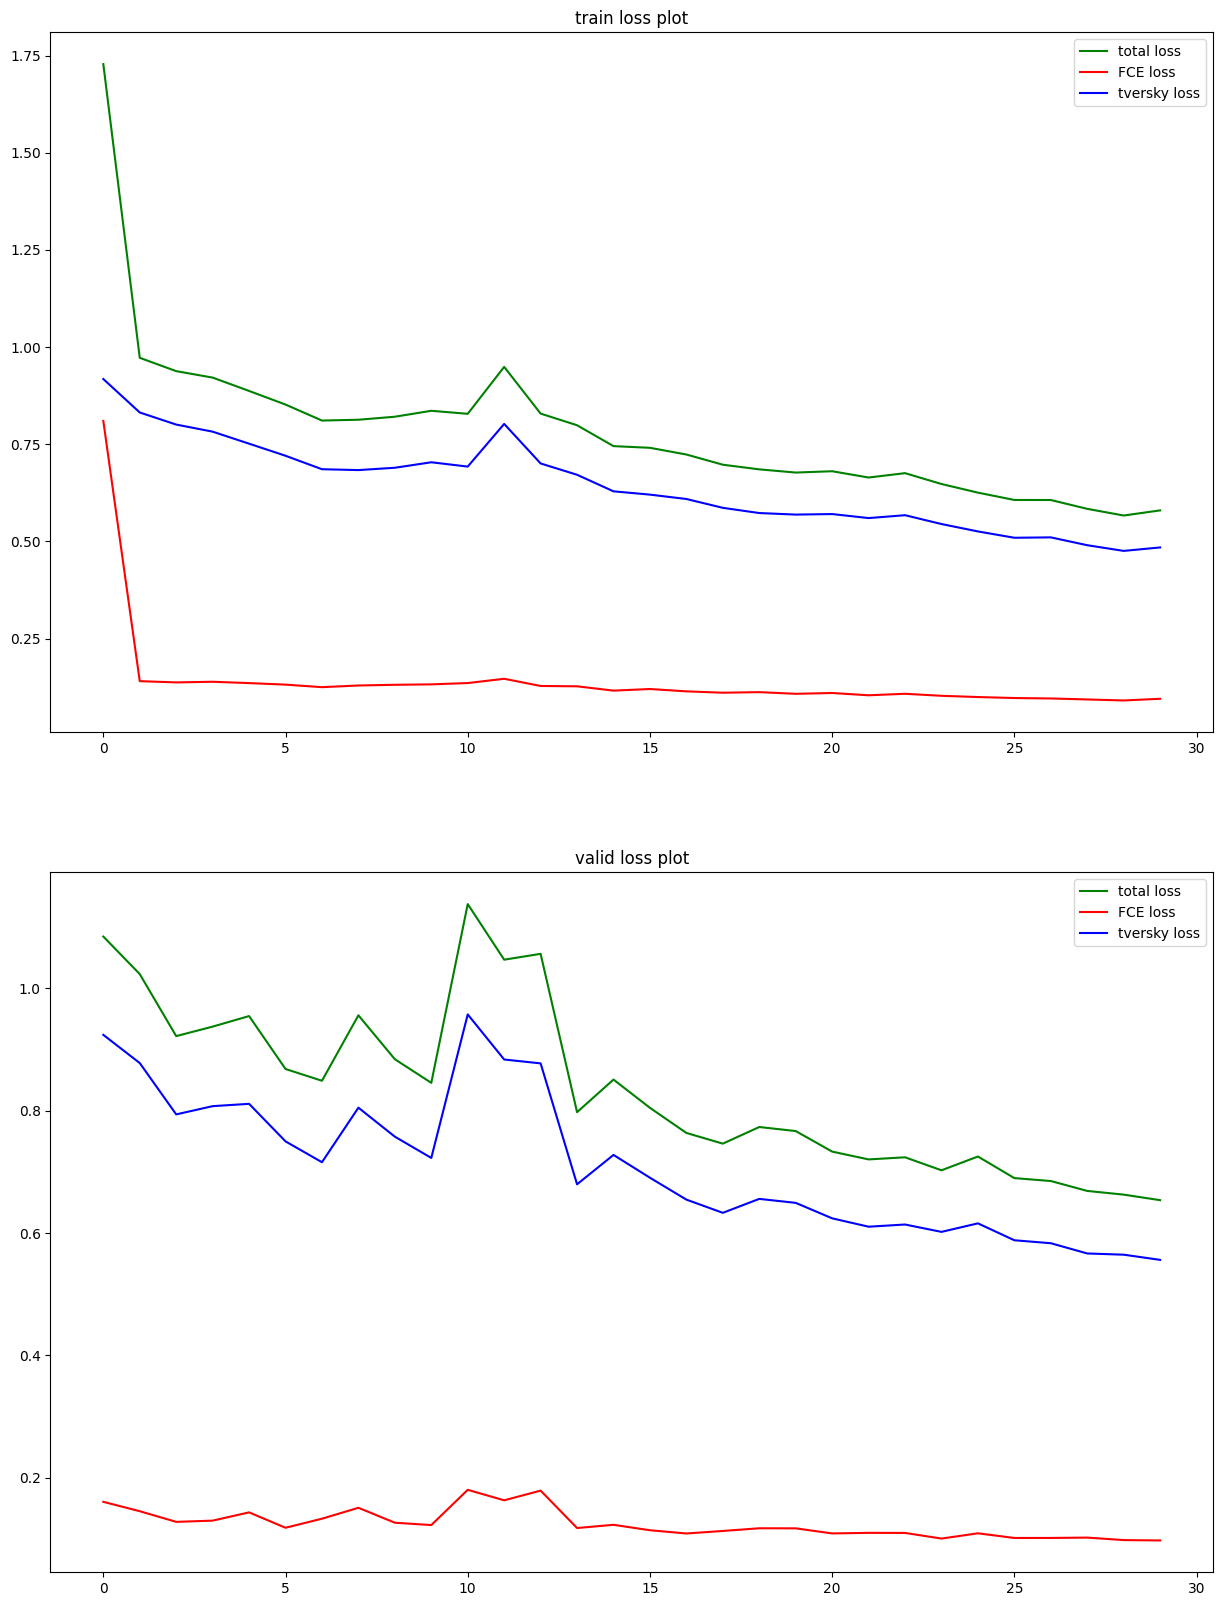

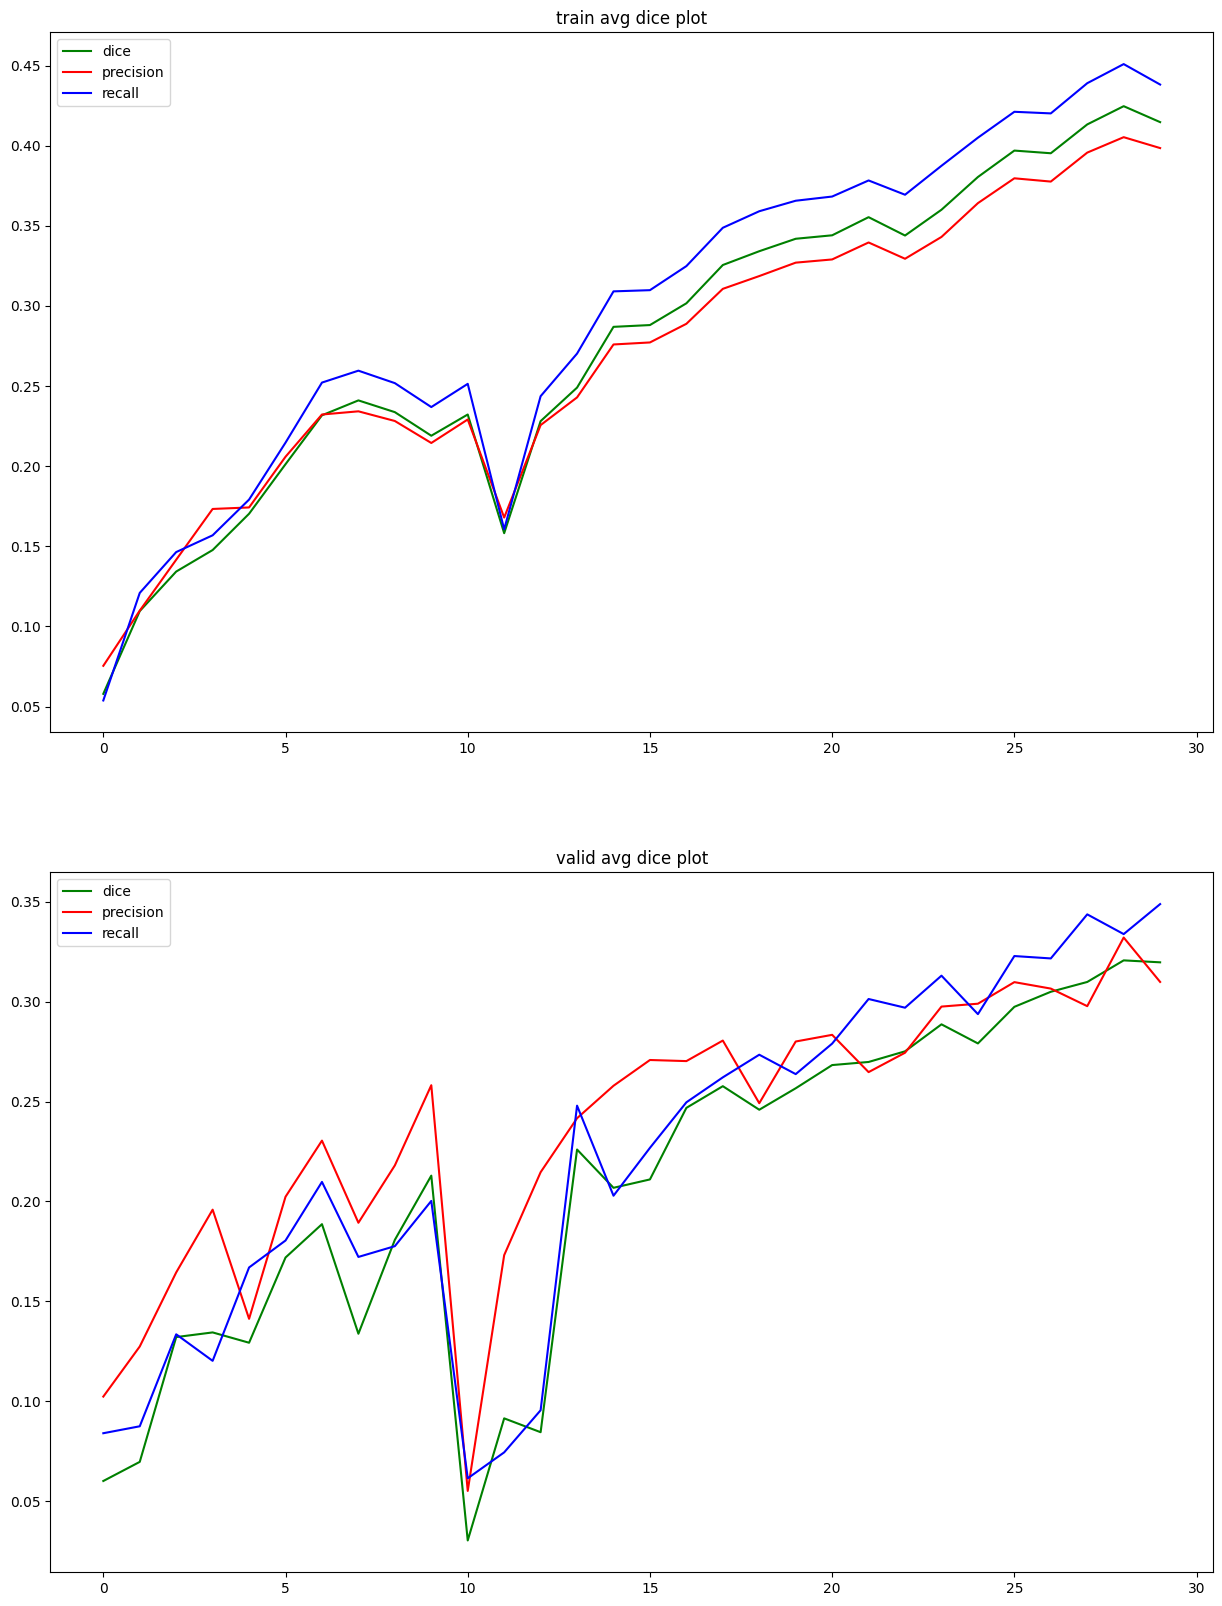

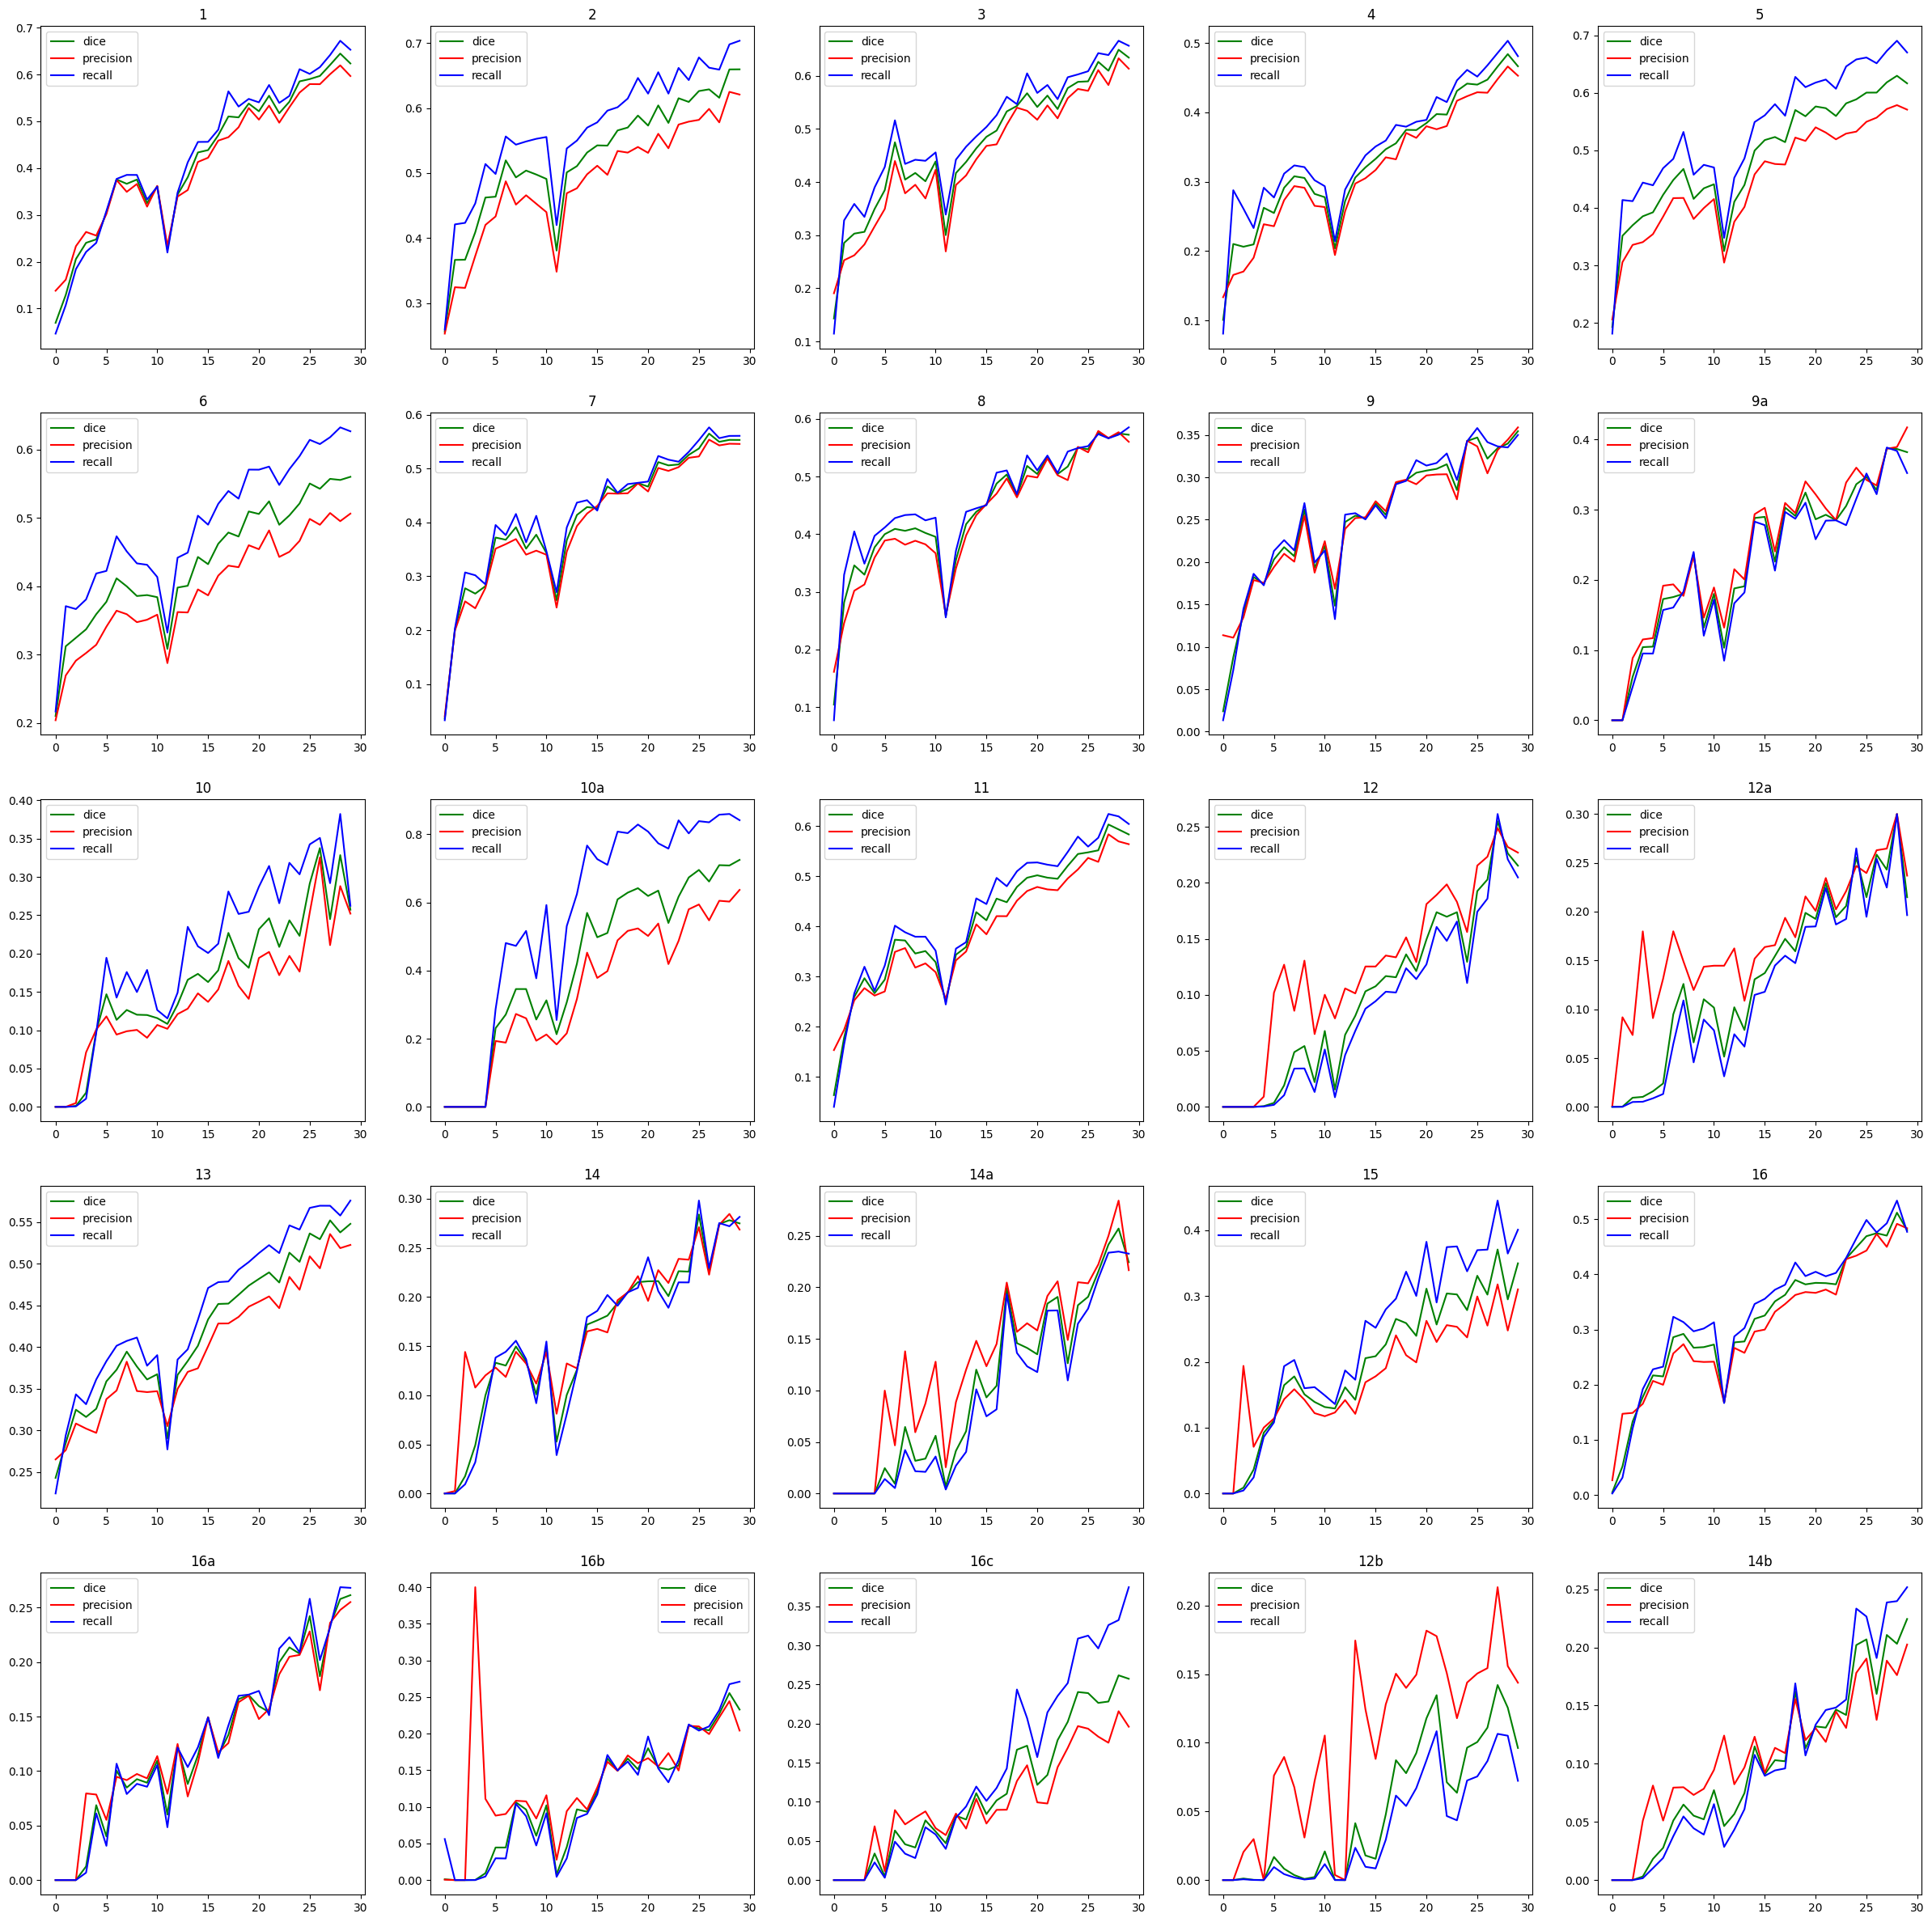

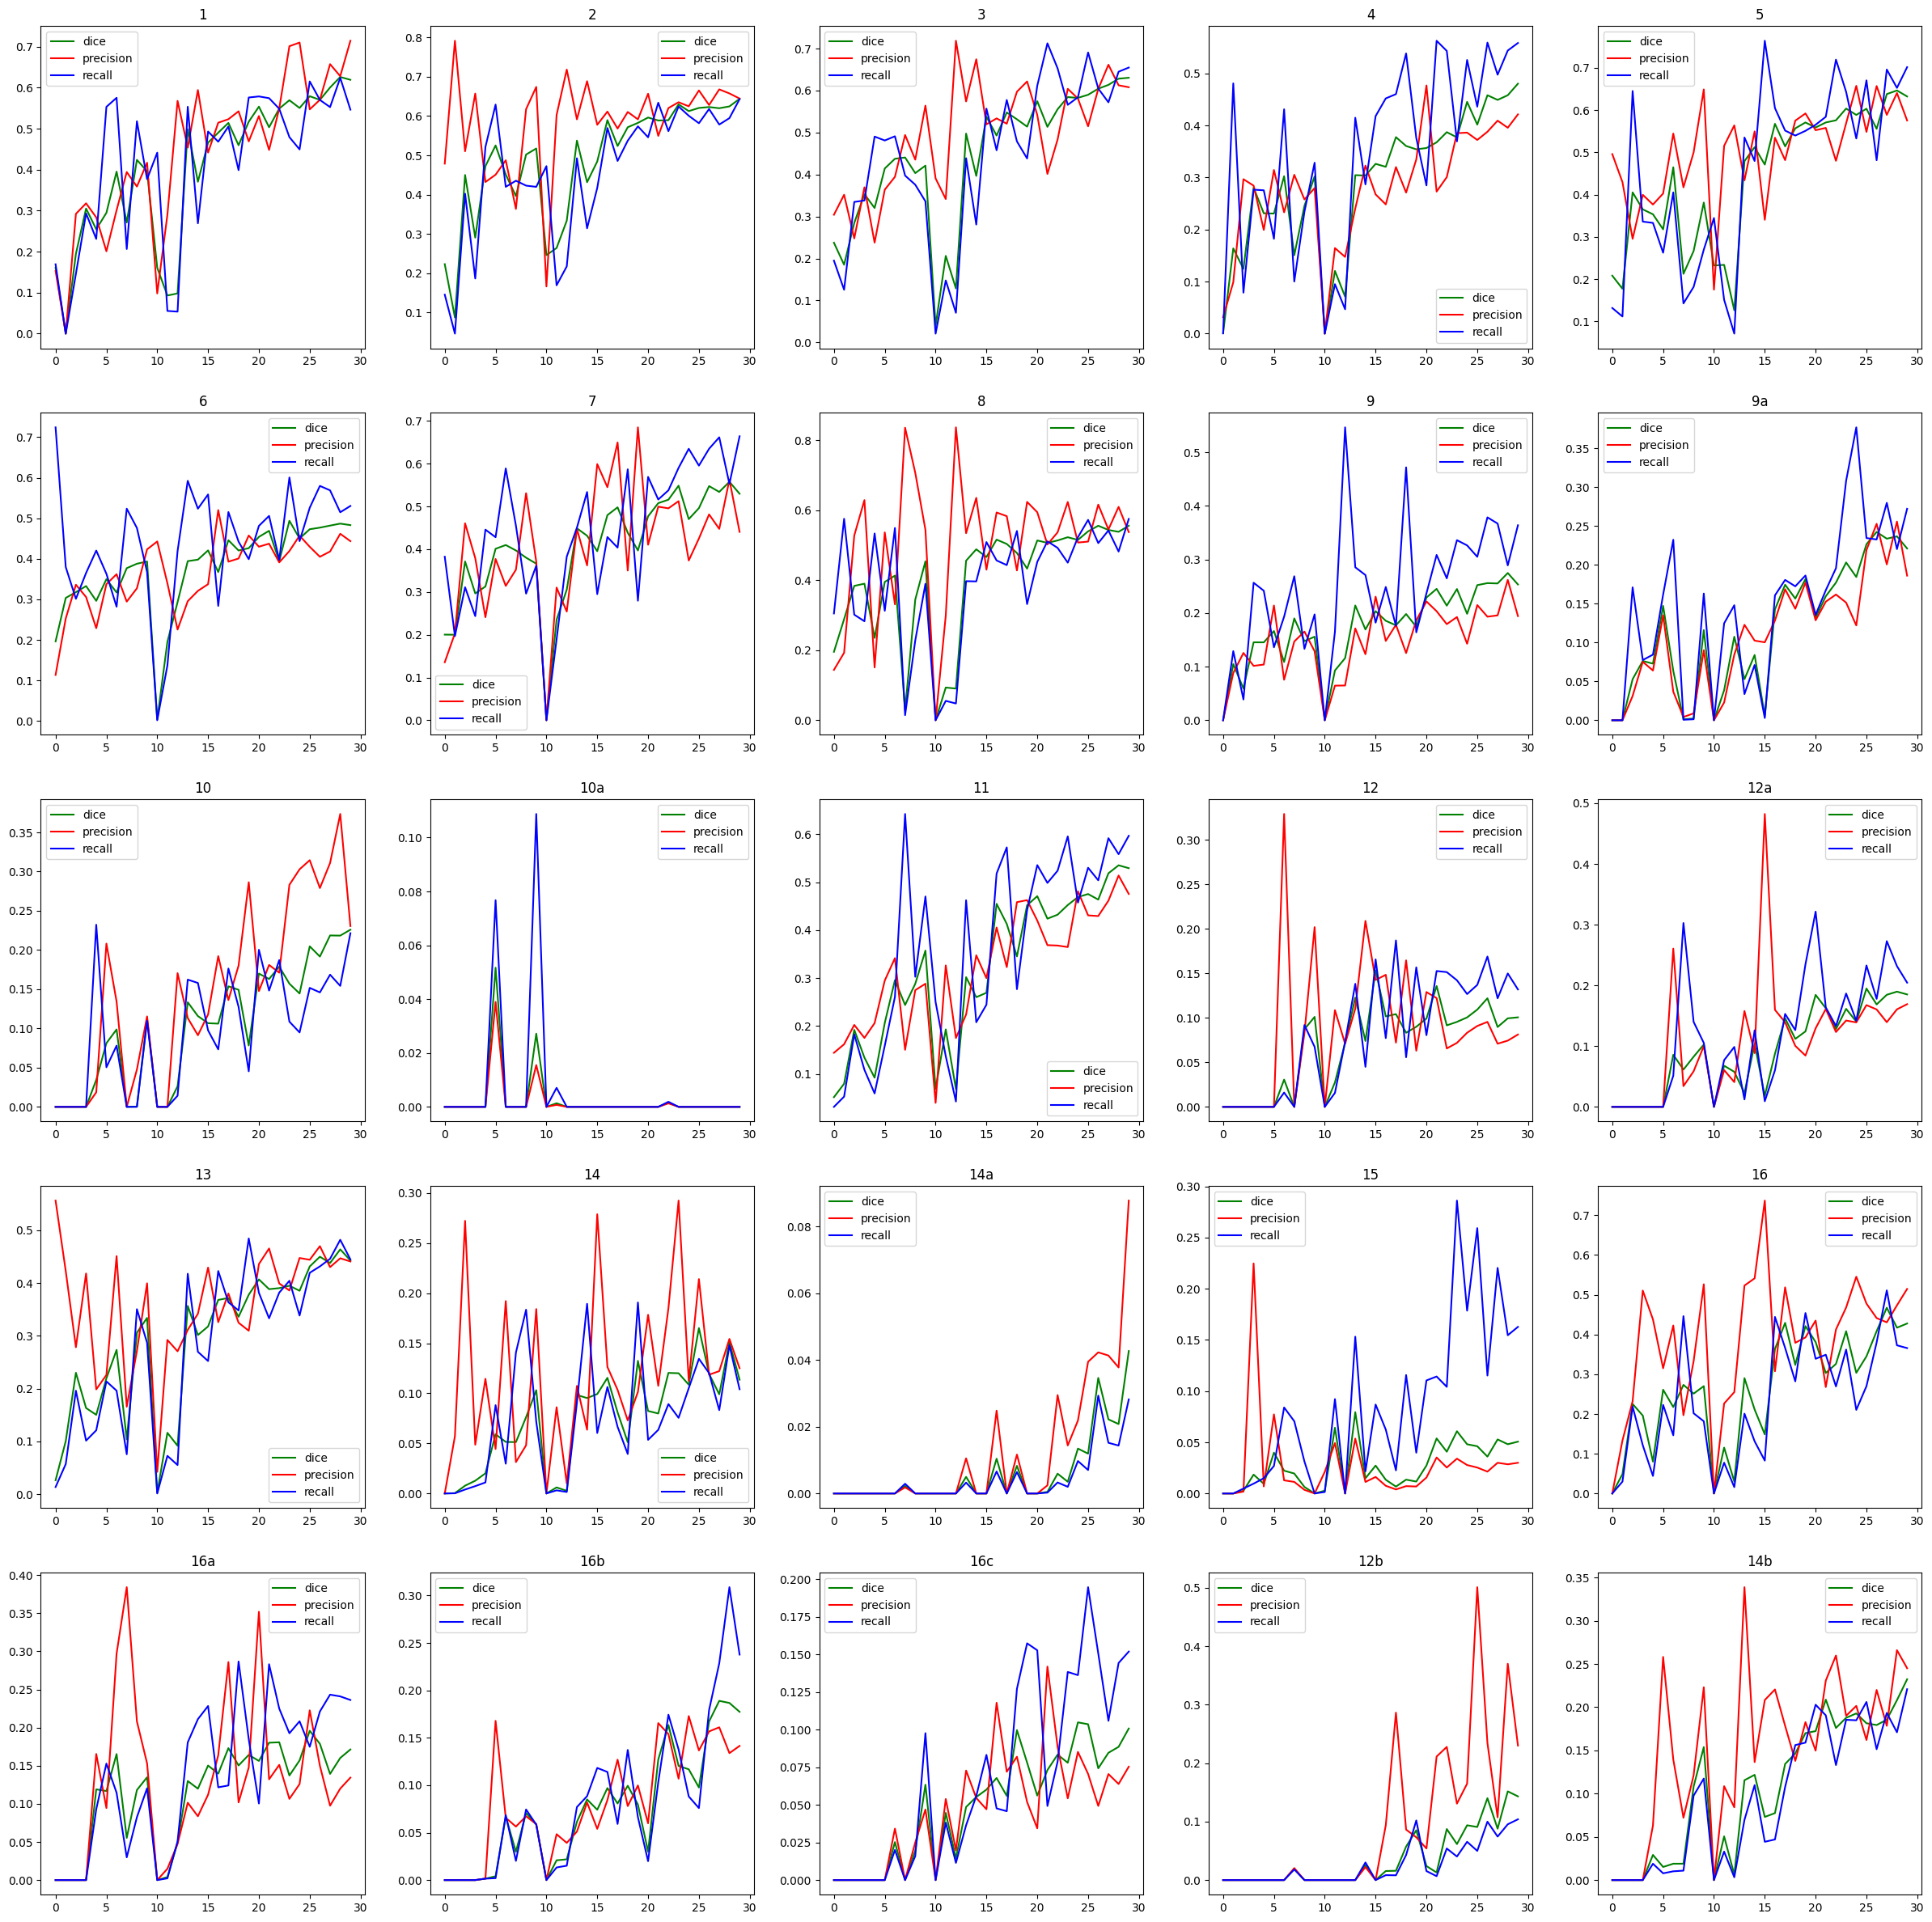

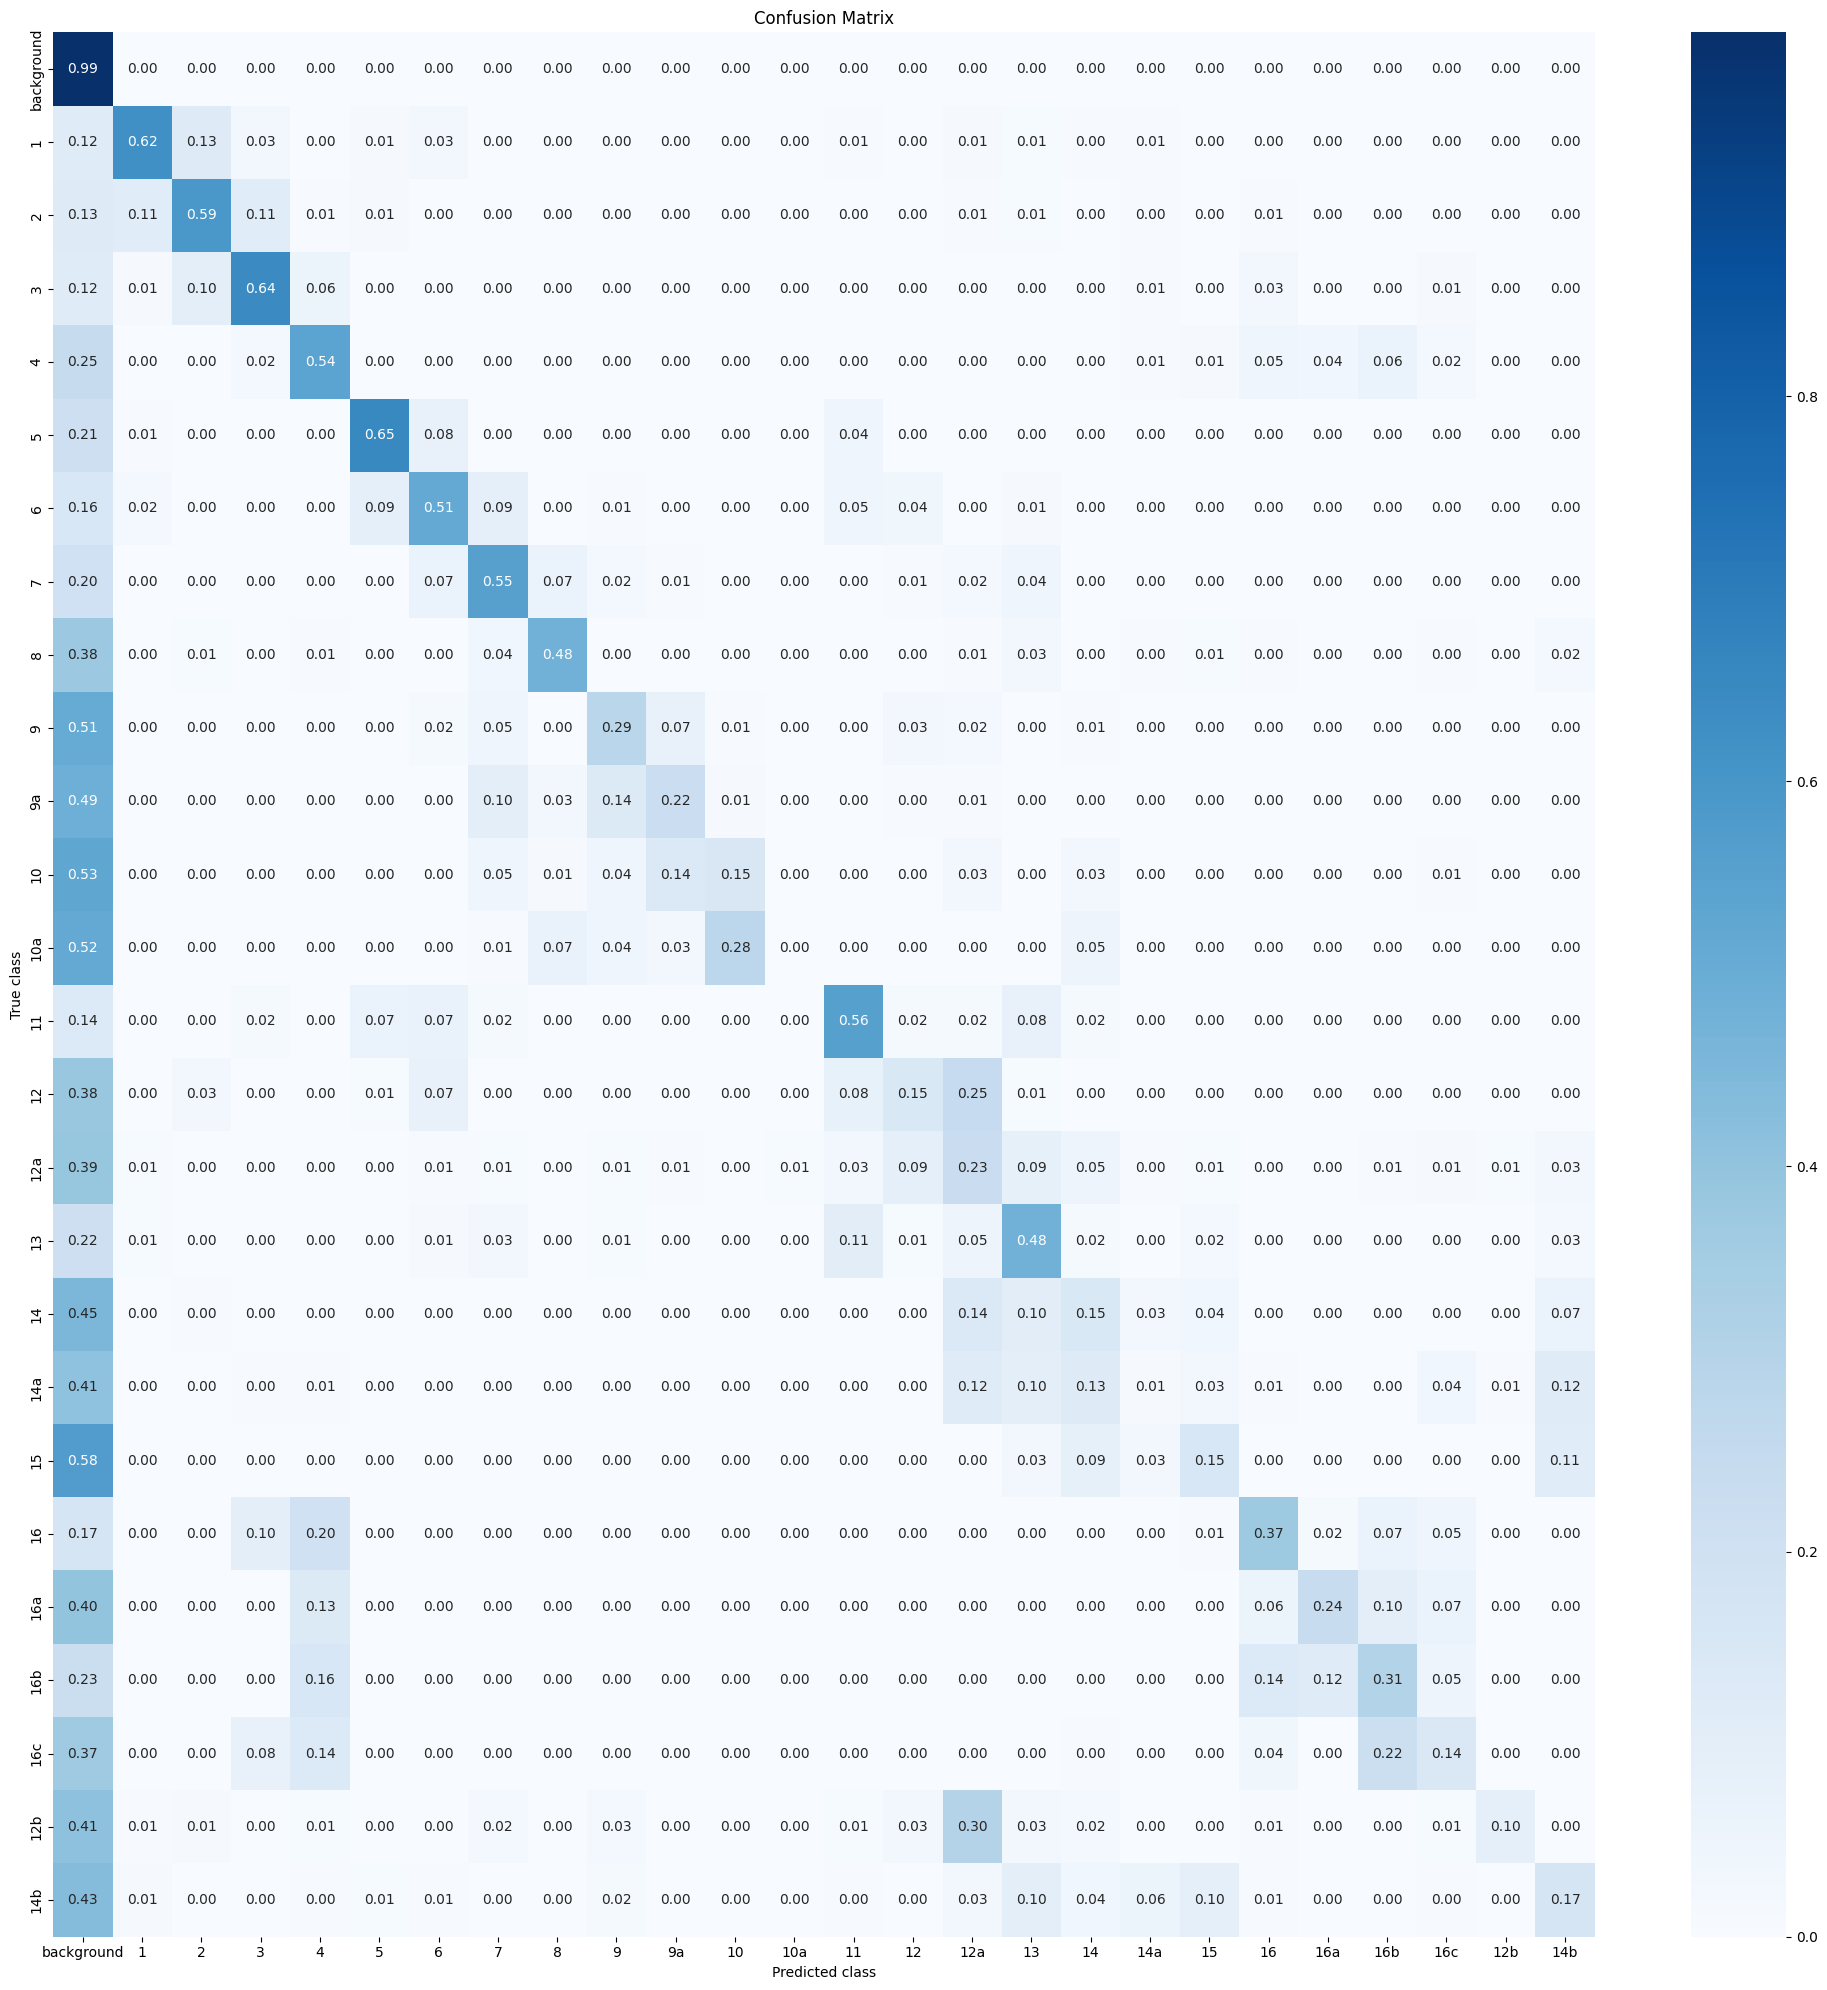

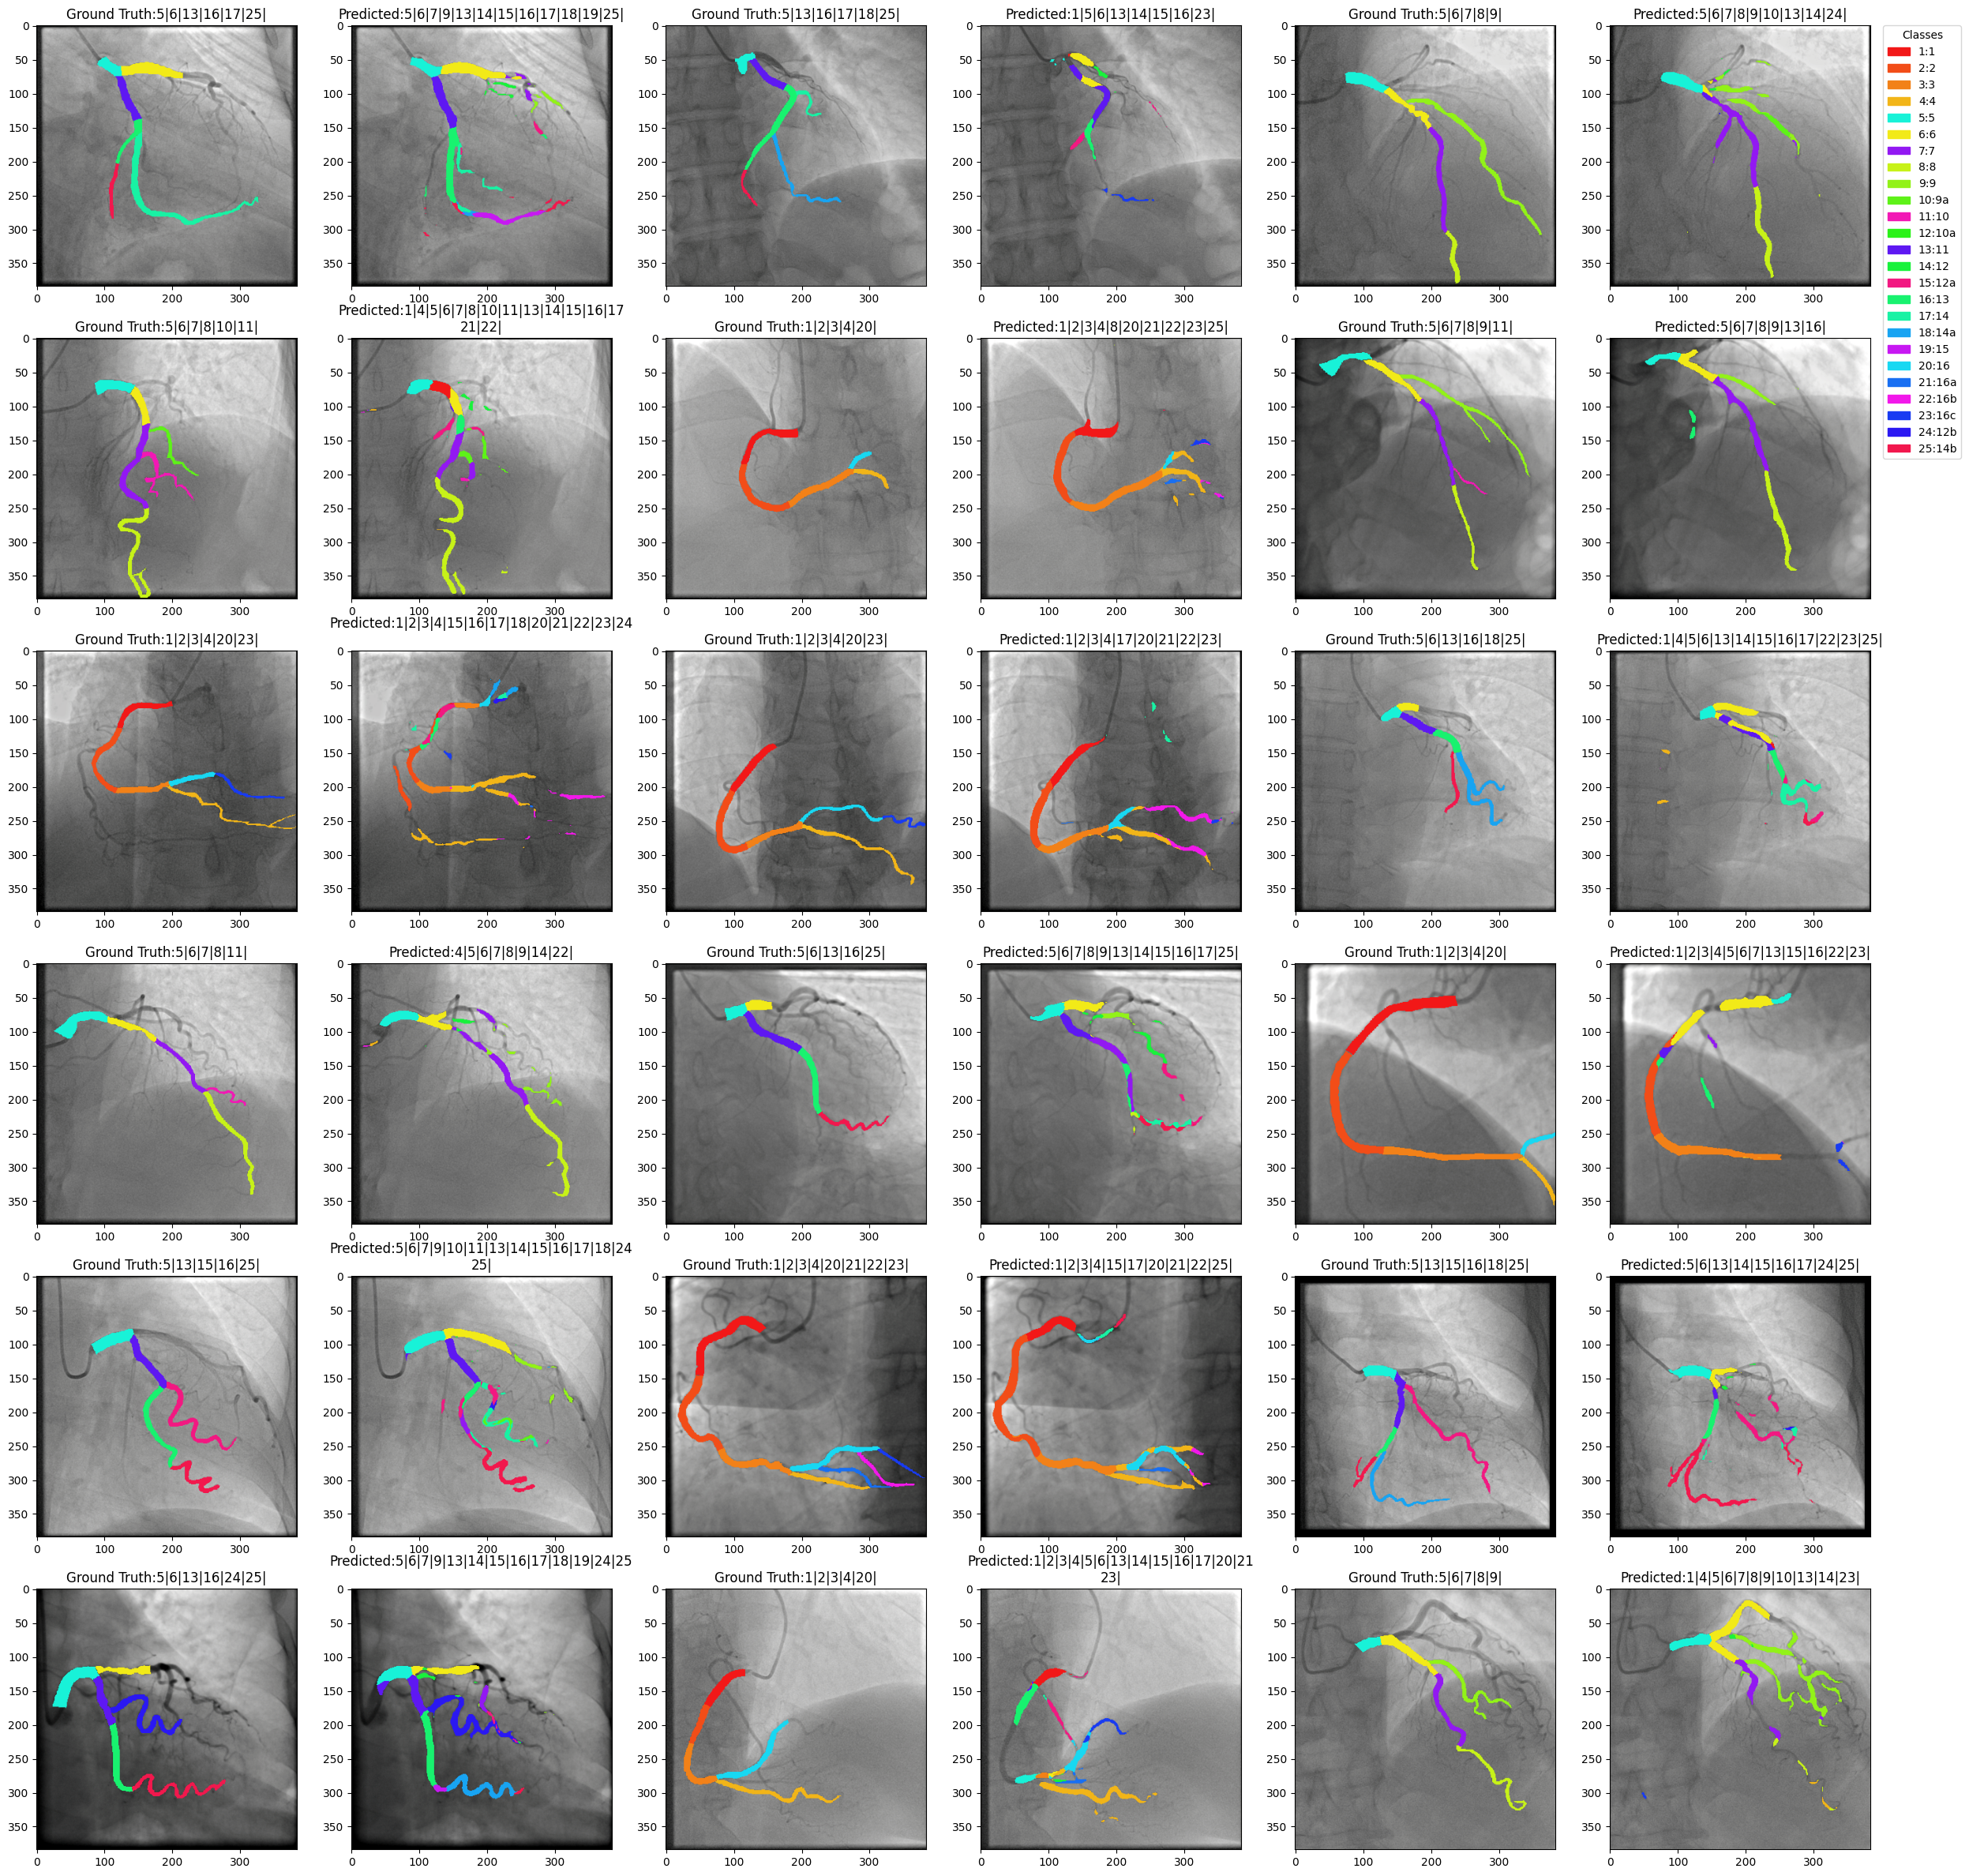

In [11]:
save_full_report(
    recorder= recorder , 
    output_base_path=args["output_base_path"],
    model=best_model,
    valid_loader=valid_loader,
    args=args,
    class_map=class_map,
    name=args["name"],
    mean=IMAGENET_MEAN,
    std=IMAGENET_STD
)